In [23]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Generating iris dataframe from csv file to train on

In [15]:
# making as_frame = True to get it as pd.Dataframe
iris = load_iris(as_frame=True)

# Wrap it in a table so we can see it clearly
# df = pd.DataFrame(iris.data, columns=iris.feature_names
df = iris.frame.rename(columns={'target':'species'}) # renaming the column target -> species 
# df['species'] = iris.target
target_dict = dict(enumerate(iris.target_names))
df['species_names'] = df['species'].map(target_dict)

### Understand the dataset

In [17]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print("Columns:", df.columns)
print(df.head)
print("\nOne row per species class count:")
print(df['species_names'].value_counts())

Shape: (150, 6)

First 5 rows:
Columns: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species', 'species_names'],
      dtype='str')
<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  ...  species  species_names
0                  5.1               3.5  ...        0         setosa
1                  4.9               3.0  ...        0         setosa
2                  4.7               3.2  ...        0         setosa
3                  4.6               3.1  ...        0         setosa
4                  5.0               3.6  ...        0         setosa
..                 ...               ...  ...      ...            ...
145                6.7               3.0  ...        2      virginica
146                6.3               2.5  ...        2      virginica
147                6.5               3.0  ...        2      virginica
148                6.2               3.4  ...        2      virginica
149             

### Split data into training and test sets

In [18]:
X = iris.data   #features (the 4 measurements)
y = iris.target #labels (0, 1, or 2 for each species)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% held back for testing also uning fixed seed so results are reproducible

In [19]:
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 120
Test samples: 30


### Train the logistic regression model

In [22]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"trainning accuracy: {train_acc:.2%}")
print(f"test accuracy:{test_acc:.2%}")

trainning accuracy: 97.50%
test accuracy:100.00%


### Plot a confusion matrix

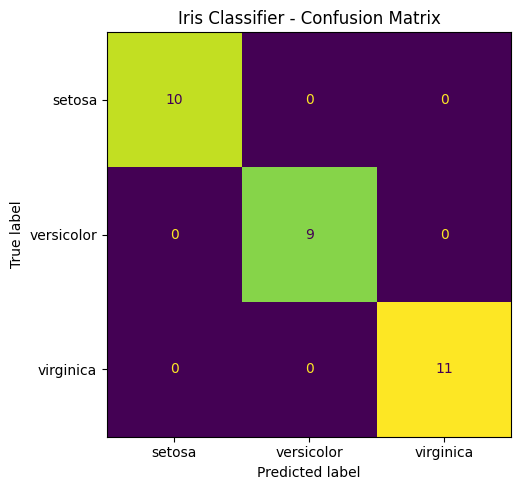

Saved: confusion_matrix.png


In [25]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels = iris.target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Iris Classifier - Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi = 150)
plt.show()

print("Saved: confusion_matrix.png")

## What I Learned Today

**The dataset:** The Iris dataset has 150 flowers with 4 measurements each. 
The goal is to predict which of 3 species a flower belongs to based on those measurements.

**What training means:** `model.fit()` shows the model labelled examples and 
adjusts its internal numbers until it can map measurements to species labels correctly.

**Train vs test split:** We hide 20% of the data during training so we can 
test on data the model has never seen. This tells us if the model actually 
generalised, or just memorised.

**The confusion matrix:** Each row is the true label, each column is the predicted label. 
Numbers on the diagonal are correct. Off-diagonal numbers are mistakes.

**One thing that surprised me:** It turned out to be a perfect model with no error.